# Phase 1 R&D — Classification Method Bake-off (v2: rebuilt on a sound foundation)

**Question this notebook answers:** which method should the production
`app/classification/` stage use to map extracted attacker-behaviour text to
**MITRE ATT&CK for ICS** techniques?

This is a rebuild. A critical re-read of the first version of this notebook found the
*methods were sound but the measurement was not* — three foundation problems, all fixed
here:

1. **The metric was unfair and self-capping.** Forcing every method to emit exactly
   `top_k=3` predictions capped a *perfect* method's precision at ~0.3-0.6 depending on
   the true label count, while LLM methods emitting a variable count could hit 1.0 — an
   apples-to-oranges comparison. **Fix:** rank-based metrics (MRR, MAP, Recall@k) that
   score a method's full ranking, no forced cutoff.
2. **The dataset was far too small** (10-16 hand-written examples, 79 classes) to rank
   methods reliably, and the original conclusion was drawn on synthetic text that
   structurally favoured embeddings (it echoed technique names). **Fix:** the primary
   eval set is now **~238 real, MITRE-documented procedure examples** — genuine
   citation-backed attacker behaviour (Sandworm/Ukraine, Triton, PIPEDREAM, KillDisk…),
   mined from the same STIX bundle this project already downloads.
3. **Two notebooks ran on two different datasets**, making "did method X actually
   improve" impossible to answer cleanly. This notebook and its companion
   `classification_improvements.ipynb` now share one foundation (`lib/eval_data.py`,
   `lib/metrics.py`'s rank functions) so ablations are isolated, one variable at a time.

Four methods are compared, all scored identically:

| | Method | How it ranks |
|---|---|---|
| **A** | Embeddings | Cosine similarity, behaviour text vs. every technique description. |
| **B** | LLM only | Local LLM ranks the full 79-technique catalogue directly (no retrieval). |
| **C** | Hybrid | Embeddings retrieve top-N candidates; LLM ranks among just those. |
| **D** | Retrieve + rerank | Embeddings retrieve top-N; a cross-encoder reranker (no LLM) re-orders them. |

**Leakage guard (checked, not just asserted):** the embedded technique *corpus* is
name + tactics + description only. Procedure/synthetic/real behaviour text is the
EVAL set and is never added to the corpus — checked explicitly in section 3.

> ⚠️ **Honest caveats, stated up front:**
> - The LLM here is a small **local** model (`qwen2.5:7b` via Ollama), not a frontier
>   model — its scores are a floor for LLM-based methods, not a ceiling.
> - MITRE procedure examples are labeled **single-technique** per relationship, even
>   though a narrative sometimes touches other techniques in passing (a real property
>   of the source data — see the worked example in section 3, not a parsing bug).
>   Rank metrics tolerate this reasonably well; still worth keeping in mind.
> - No ICS-domain-specific embedding model exists via the local `fastembed` library —
>   `bge`/`ms-marco` are general-purpose web-search models. This is a real ceiling on
>   A and D, not a bug, and is discussed in the decision at the end.

## 1. Setup & environment check

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_research_dir() -> Path:
    here = Path.cwd()
    for candidate in (here, here / "research", here.parent):
        if (candidate / "lib" / "attack_data.py").exists():
            return candidate
    raise RuntimeError("Could not locate the research/ directory — run from research/.")


RESEARCH_DIR = _find_research_dir()
DATA_DIR = RESEARCH_DIR / "data"
sys.path.insert(0, str(RESEARCH_DIR))

from lib import attack_data, eval_data, metrics, ollama_client, rerank  # noqa: E402

# --- Knobs ---
LLM_MODEL = "qwen2.5:7b"            # fast, reliable structured JSON (see prior notebook:
                                     # larger "thinking" models were slower AND less reliable)
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"   # best of 3 tested previously (small/base/large)
QUERY_INSTRUCTION = "Represent this sentence for searching relevant passages: "
RERANKER_MODEL = "Xenova/ms-marco-MiniLM-L-6-v2"
LLM_RANK_SIZE = 5                   # LLM methods always return exactly this many, ranked
EVAL_N = 80                         # stratified sample size for the LLM-cost-limited
                                     # 4-way comparison — raise this if you want tighter
                                     # numbers; embeddings/reranker calls are cheap so A
                                     # and D are ALSO scored on the full eval set (~259)
                                     # as an appendix regardless of EVAL_N.
SAMPLE_SEED = 42

cache = ollama_client.ResponseCache(DATA_DIR / ".llm_cache.json")

print(f"research dir : {RESEARCH_DIR}")
print(f"LLM model    : {LLM_MODEL}   embed model: {EMBEDDING_MODEL}   reranker: {RERANKER_MODEL}")
print(f"EVAL_N       : {EVAL_N}   LLM_RANK_SIZE: {LLM_RANK_SIZE}")
print(f"cache entries: {len(cache)} (path: {cache.path})")

research dir : C:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\research
LLM model    : qwen2.5:7b   embed model: BAAI/bge-base-en-v1.5   reranker: Xenova/ms-marco-MiniLM-L-6-v2
EVAL_N       : 80   LLM_RANK_SIZE: 5
cache entries: 100 (path: C:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\research\data\.llm_cache.json)


C:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
available = ollama_client.list_models()
print("Ollama models available:", available)
assert LLM_MODEL in available, f"Model '{LLM_MODEL}' not found. Run:  ollama pull {LLM_MODEL}"

reply = ollama_client.ping(LLM_MODEL)
print(f"Ping '{LLM_MODEL}' -> {reply!r}")
assert reply, "Empty response — is the Ollama daemon healthy?"
print("Environment OK.")

Ollama models available: ['qwen2.5:7b', 'gemma4:e2b', 'phi4-mini:latest', 'llama3.2:3b', 'qwen2.5-coder:1.5b', 'qwen3.5:4b', 'qwen2.5:3b', 'qwen3.5:9b']


Ping 'qwen2.5:7b' -> 'Ready'
Environment OK.


## 2. Load the technique corpus

The classification *corpus* — what every method ranks against. Name + tactics +
description only (no procedure/behaviour text here — that's the eval set, loaded
separately in section 3, and kept structurally apart to guard against leakage).

In [3]:
techniques = attack_data.fetch_and_cache(DATA_DIR / "attack_ics_techniques.json")
technique_by_id = {t.id: t for t in techniques}
valid_ids = set(technique_by_id)
corpus_texts = [f"{t.name}. {t.description}" for t in techniques]
print(f"Loaded {len(techniques)} top-level ATT&CK for ICS techniques (the corpus).")

Loaded techniques from cache: C:\Users\USER\OneDrive\Desktop\Personal projects\CTI-automation-mvp\research\data\attack_ics_techniques.json
Loaded 79 top-level ATT&CK for ICS techniques (the corpus).


## 3. Load and validate the evaluation set

Three slices, unified by `lib/eval_data.py`:
- **procedure** — real MITRE-documented examples (the primary set, ~238 examples).
- **synthetic-easy / synthetic-hard** — the original hand-written examples.
- **real** — your own excerpts, if `labeled_dataset.local.jsonl` exists (optional).

Every true technique ID is validated against the corpus (catches typos loudly), and
`name_absent` is computed per example: True when none of its true techniques' names
appear verbatim in its behaviour text — a data-driven, at-scale replacement for a
hand-labeled easy/hard split, and the fairest lens for "is a method winning on lexical
overlap or genuine understanding."

In [4]:
examples = eval_data.load_eval_set(
    DATA_DIR / "procedure_examples.jsonl",
    DATA_DIR / "labeled_dataset.jsonl",
    DATA_DIR / "labeled_dataset.local.jsonl",
)
eval_data.validate_technique_ids(examples, valid_ids)
examples = eval_data.compute_name_absent(examples, technique_by_id)
eval_data.assert_no_leakage(corpus_texts, examples)  # leakage guard: passes or raises

from collections import Counter
print(f"Loaded {len(examples)} eval examples (validated, leakage-checked).")
print("By slice:      ", dict(Counter(e.slice for e in examples)))
print("By name_absent:", dict(Counter(e.name_absent for e in examples)))

# Worked example of the "one relationship, one formally-tagged technique, even when the
# narrative also touches another concept" nuance flagged in section 0 — not a bug.
_demo = next(e for e in examples if e.id == "proc-0001")
print(f"\nExample {_demo.id} (technique {_demo.true_technique_ids[0]} = "
      f"{technique_by_id[_demo.true_technique_ids[0]].name}):")
print(f"  {_demo.behavior_text}")

Loaded 259 eval examples (validated, leakage-checked).
By slice:       {'procedure': 238, 'synthetic-easy': 10, 'synthetic-hard': 6, 'real': 5}
By name_absent: {True: 236, False: 23}

Example proc-0001 (technique T0822 = External Remote Services):
  During the 2015 Ukraine Electric Power Attack, Sandworm Team used Valid Accounts taken from the Windows Domain Controller to access the control system Virtual Private Network (VPN) used by grid operators.


## 4. Method A — Embeddings

Embed the corpus once; rank every technique by cosine similarity to each example's
behaviour text. Run over the **full eval set** (cheap, no LLM) — this both feeds the
retrieval-ceiling analysis (section 5) and gives Method A a full-confidence score in
the results appendix (section 11), not just the `EVAL_N` sample.

In [5]:
from fastembed import TextEmbedding


def l2_normalise(mat: np.ndarray) -> np.ndarray:
    return mat / np.linalg.norm(mat, axis=1, keepdims=True)


embedder = TextEmbedding(model_name=EMBEDDING_MODEL)
corpus_vecs = l2_normalise(np.array(list(embedder.embed(corpus_texts))))


def rank_by_embedding(text: str) -> list[str]:
    """Return ALL technique IDs ranked by cosine similarity to `text`, best first."""
    query = np.array(list(embedder.embed([QUERY_INSTRUCTION + text])))[0]
    query = query / np.linalg.norm(query)
    sims = corpus_vecs @ query
    order = np.argsort(-sims)
    return [techniques[i].id for i in order]


t0 = time.time()
method_a_all = [
    metrics.MethodResult(
        report_id=ex.id, true_ids=ex.true_technique_ids, ranked_ids=rank_by_embedding(ex.behavior_text)
    )
    for ex in examples
]
print(f"Method A: ranked all {len(techniques)} techniques for all {len(examples)} "
      f"eval examples in {time.time()-t0:.1f}s.")

_ex = next(m for m in method_a_all if m.report_id == "proc-0001")
print(f"\nWorked example (proc-0001, true={_ex.true_ids}):")
for rank, tid in enumerate(_ex.ranked_ids[:5], start=1):
    mark = "  <- TRUE" if tid in _ex.true_ids else ""
    print(f"  {rank}. {tid}  {technique_by_id[tid].name}{mark}")

Method A: ranked all 79 techniques for all 259 eval examples in 7.0s.

Worked example (proc-0001, true=['T0822']):
  1. T0802  Automated Collection
  2. T0814  Denial of Service
  3. T0859  Valid Accounts
  4. T0846  Remote System Discovery
  5. T0847  Replication Through Removable Media


## 5. Retrieval ceiling — choosing `HYBRID_RETRIEVAL_N`

Computed on the **full eval set** (free, since Method A already ran over everything):
for increasing candidate-set sizes N, what fraction of true techniques are anywhere in
the top-N? This separates a retrieval problem from a verification problem, and grounds
`HYBRID_RETRIEVAL_N` in data rather than a guess.

recall@5   = 0.600
recall@10  = 0.726
recall@20  = 0.842
recall@30  = 0.905
recall@50  = 0.967

-> HYBRID_RETRIEVAL_N = 30 (recall@30 = 0.905)


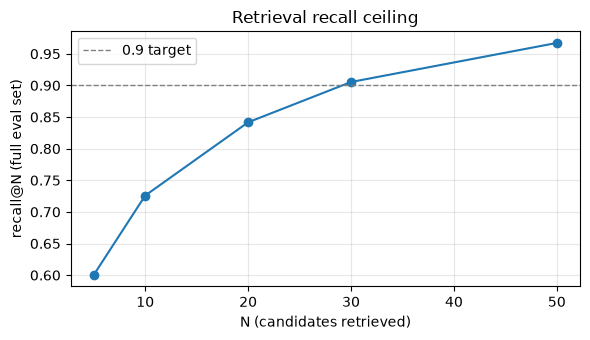

In [6]:
candidate_ns = [5, 10, 20, 30, 50]
recall_curve = {n: metrics.recall_at_n(method_a_all, n) for n in candidate_ns}
for n, r in recall_curve.items():
    print(f"recall@{n:<3} = {r:.3f}")

HYBRID_RETRIEVAL_N = next((n for n, r in recall_curve.items() if r >= 0.9), candidate_ns[-1])
print(f"\n-> HYBRID_RETRIEVAL_N = {HYBRID_RETRIEVAL_N} "
      f"(recall@{HYBRID_RETRIEVAL_N} = {recall_curve[HYBRID_RETRIEVAL_N]:.3f})")

plt.figure(figsize=(6, 3.5))
plt.plot(list(recall_curve.keys()), list(recall_curve.values()), marker="o")
plt.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="0.9 target")
plt.xlabel("N (candidates retrieved)")
plt.ylabel("recall@N (full eval set)")
plt.title("Retrieval recall ceiling")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Stratified sample for the LLM-cost-limited comparison

LLM calls (Methods B and C) are the expensive part. `sample_by_technique` draws a
deterministic, seeded, stratified sample of `EVAL_N` examples that spreads across as
much of the technique space as possible, rather than risking a biased blind-random
draw. Methods A and D already ran over everything and are also scored on this same
sample below for a fair 4-way comparison — plus their full-set scores in the appendix.

In [7]:
sample = eval_data.sample_by_technique(examples, EVAL_N, seed=SAMPLE_SEED)
sample_ids = {ex.id for ex in sample}
covered = {tid for ex in sample for tid in ex.true_technique_ids}

print(f"Sampled {len(sample)} examples covering {len(covered)}/{len(valid_ids)} techniques.")
print("Sample by slice:", dict(Counter(ex.slice for ex in sample)))

method_a_sample = [m for m in method_a_all if m.report_id in sample_ids]
assert len(method_a_sample) == len(sample)

Sampled 80 examples covering 73/79 techniques.
Sample by slice: {'procedure': 74, 'synthetic-hard': 3, 'real': 1, 'synthetic-easy': 2}


## 7. Method B — LLM only

The LLM sees the **entire** 79-technique catalogue and no retrieval. It is asked for a
**ranked list of exactly `LLM_RANK_SIZE`** technique IDs (not "up to N") — schema-
constrained (`ollama_client.build_schema` with `min_predictions=max_predictions`), so
under-prediction (a real problem in the earlier version of this notebook) is no longer
possible, and out-of-vocabulary IDs are structurally impossible. Run only on the
stratified `sample` (LLM calls are the expensive part).

In [8]:
_RANKING_FORMAT = f"""Always return exactly {LLM_RANK_SIZE} entries, ranked most-confident \
first — even entries you are unsure about; ranking position is what gets scored, not just \
whether you include the right one. Reply with ONLY this JSON shape:
{{"predicted_techniques": [
  {{"technique_id": "<id>", "rank": 1}},
  {{"technique_id": "<id>", "rank": 2}},
  {{"technique_id": "<id>", "rank": 3}},
  {{"technique_id": "<id>", "rank": 4}},
  {{"technique_id": "<id>", "rank": 5}}
]}}
Replace <id> with a real technique ID from the catalogue above. A single behaviour \
often maps to more than one technique — rank plausible alternatives too, not just the \
single best match."""

_catalogue = "\n".join(f"{t.id}: {t.name} - {t.description[:110]}" for t in techniques)


def build_llm_only_prompt(behavior_text: str) -> str:
    return f"""You are a cyber threat intelligence analyst mapping attacker behaviour to \
MITRE ATT&CK for ICS techniques.

TECHNIQUE CATALOGUE (ID: name - description):
{_catalogue}

BEHAVIOUR TO CLASSIFY:
"{behavior_text}"

{_RANKING_FORMAT}"""


def run_llm_method(model: str, prompt_fn, valid_id_set_fn, label: str) -> list[metrics.MethodResult]:
    results = []
    t0 = time.time()
    for i, ex in enumerate(sample, 1):
        prompt = prompt_fn(ex.behavior_text)
        pred = ollama_client.classify_structured(
            model, prompt, valid_id_set_fn(ex),
            max_predictions=LLM_RANK_SIZE, min_predictions=LLM_RANK_SIZE, cache=cache,
        )
        results.append(
            metrics.MethodResult(
                report_id=ex.id, true_ids=ex.true_technique_ids, ranked_ids=pred.ranked_ids,
                parse_failure=pred.parse_failure, hallucinated_id_count=len(pred.hallucinated),
            )
        )
        if i % 10 == 0 or i == len(sample):
            print(f"  [{label}] {i}/{len(sample)}  ({time.time()-t0:.0f}s elapsed)")
    pf = sum(r.parse_failure for r in results)
    print(f"{label}: done. parse failures {pf}/{len(results)}  ({time.time()-t0:.0f}s total)")
    return results


method_b_results = run_llm_method(LLM_MODEL, build_llm_only_prompt, lambda ex: valid_ids, "B: LLM-only")

  [B: LLM-only] 10/80  (16s elapsed)


  [B: LLM-only] 20/80  (31s elapsed)


  [B: LLM-only] 30/80  (46s elapsed)


  [B: LLM-only] 40/80  (62s elapsed)


  [B: LLM-only] 50/80  (80s elapsed)


  [B: LLM-only] 60/80  (108s elapsed)


  [B: LLM-only] 70/80  (137s elapsed)


  [B: LLM-only] 80/80  (164s elapsed)
B: LLM-only: done. parse failures 0/80  (164s total)


## 8. Method C — Hybrid (embeddings retrieve, LLM ranks)

Retrieval reuses Method A's already-computed ranking (top `HYBRID_RETRIEVAL_N`); the
LLM then ranks the top `LLM_RANK_SIZE` among just those candidates — a much smaller,
focused prompt than Method B's full catalogue.

In [9]:
def build_hybrid_prompt(behavior_text: str, candidate_ids: list[str]) -> str:
    lines = [
        f"{tid}: {technique_by_id[tid].name} - {technique_by_id[tid].description_full[:220]}"
        for tid in candidate_ids
    ]
    catalogue = "\n".join(lines)
    return f"""You are a cyber threat intelligence analyst mapping attacker behaviour to \
MITRE ATT&CK for ICS techniques.

CANDIDATE TECHNIQUES (retrieved by similarity; choose from these ONLY):
{catalogue}

BEHAVIOUR TO CLASSIFY:
"{behavior_text}"

{_RANKING_FORMAT}"""


method_a_by_id = {m.report_id: m for m in method_a_sample}

method_c_results = []
t0 = time.time()
for i, ex in enumerate(sample, 1):
    candidate_ids = method_a_by_id[ex.id].ranked_ids[:HYBRID_RETRIEVAL_N]
    prompt = build_hybrid_prompt(ex.behavior_text, candidate_ids)
    pred = ollama_client.classify_structured(
        LLM_MODEL, prompt, set(candidate_ids),
        max_predictions=LLM_RANK_SIZE, min_predictions=LLM_RANK_SIZE, cache=cache,
    )
    method_c_results.append(
        metrics.MethodResult(
            report_id=ex.id, true_ids=ex.true_technique_ids, ranked_ids=pred.ranked_ids,
            parse_failure=pred.parse_failure, hallucinated_id_count=len(pred.hallucinated),
        )
    )
    if i % 10 == 0 or i == len(sample):
        print(f"  [C: hybrid] {i}/{len(sample)}  ({time.time()-t0:.0f}s elapsed)")

pf = sum(r.parse_failure for r in method_c_results)
print(f"C: hybrid: done. parse failures {pf}/{len(method_c_results)}  ({time.time()-t0:.0f}s total)")

  [C: hybrid] 10/80  (32s elapsed)


  [C: hybrid] 20/80  (64s elapsed)


  [C: hybrid] 30/80  (96s elapsed)


  [C: hybrid] 40/80  (127s elapsed)


  [C: hybrid] 50/80  (159s elapsed)


  [C: hybrid] 60/80  (190s elapsed)


  [C: hybrid] 70/80  (222s elapsed)


  [C: hybrid] 80/80  (253s elapsed)
C: hybrid: done. parse failures 0/80  (253s total)


## 9. Method D — Retrieve + cross-encoder rerank (no LLM)

Same retrieval as Method C, but verification is a small dedicated cross-encoder
reranker instead of an LLM: fully deterministic, architecturally incapable of
hallucinating (it only ever reorders candidates it was given), and cheap enough to run
over the **full eval set**, not just the sample.

In [10]:
reranker = rerank.CrossEncoderReranker(RERANKER_MODEL)

t0 = time.time()
method_d_all = []
for m in method_a_all:
    candidate_ids = m.ranked_ids[:HYBRID_RETRIEVAL_N]
    candidate_texts = [
        (tid, f"{technique_by_id[tid].name}. {technique_by_id[tid].description_full}")
        for tid in candidate_ids
    ]
    ex_text = next(e.behavior_text for e in examples if e.id == m.report_id)
    reranked = reranker.rerank(ex_text, candidate_texts)
    method_d_all.append(
        metrics.MethodResult(
            report_id=m.report_id, true_ids=m.true_ids,
            ranked_ids=[c.technique_id for c in reranked],
        )
    )
print(f"Method D: reranked candidates for all {len(method_d_all)} eval examples "
      f"in {time.time()-t0:.1f}s.")

method_d_sample = [m for m in method_d_all if m.report_id in sample_ids]

Method D: reranked candidates for all 259 eval examples in 477.8s.


## 10. Results — the fair 4-way comparison (on the `EVAL_N` sample)

Primary metrics: **MRR** and **Recall@3** (fairest across methods — no forced cutoff).
Recall@1 = top-1 accuracy; MAP rewards ranking *every* true technique highly, not just
the first one; Recall@5 shown for reference (favours methods that always emit 5, i.e.
B and C by construction, vs A/D which can rank a true technique outside a small window).

In [11]:
rank_results = {
    "A: Embeddings": method_a_sample,
    "B: LLM-only": method_b_results,
    "C: Hybrid": method_c_results,
    "D: Retrieve+rerank": method_d_sample,
}

rank_scores = {name: metrics.rank_score_method(name, res) for name, res in rank_results.items()}

results_table = pd.DataFrame(
    [
        {
            "method": name,
            "MRR": round(s.mrr, 3),
            "MAP": round(s.map, 3),
            "Recall@1": round(s.recall_at_k[1], 3),
            "Recall@3": round(s.recall_at_k[3], 3),
            "Recall@5": round(s.recall_at_k[5], 3),
        }
        for name, s in rank_scores.items()
    ]
).set_index("method")
results_table

,MRR,MAP,Recall@1,Recall@3,Recall@5
method,,,,,
A: Embeddings,0.511,0.506,0.388,0.562,0.619
B: LLM-only,0.364,0.360,0.287,0.406,0.487
C: Hybrid,0.540,0.538,0.456,0.619,0.644
D: Retrieve+rerank,0.559,0.556,0.431,0.631,0.706


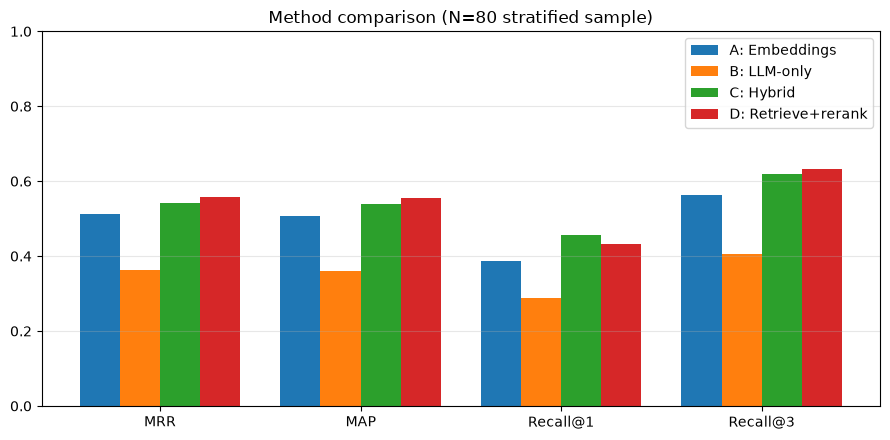

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_metrics = ["MRR", "MAP", "Recall@1", "Recall@3"]
x = np.arange(len(plot_metrics))
width = 0.2
for i, name in enumerate(rank_scores):
    s = rank_scores[name]
    vals = [s.mrr, s.map, s.recall_at_k[1], s.recall_at_k[3]]
    ax.bar(x + (i - 1.5) * width, vals, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1)
ax.set_title(f"Method comparison (N={EVAL_N} stratified sample)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Per-slice breakdown, and the full-eval-set appendix for A & D

**Per-slice** (on the sample): does a method's edge hold up on `procedure` (real,
MITRE-documented) examples, or only on the hand-written `synthetic-easy` ones?

**Full-set appendix**: Methods A and D ran on the *entire* eval set (no LLM cost), so
their scores here carry much tighter statistical confidence than the `EVAL_N`-sample
numbers above — read this as the more trustworthy number for those two methods
specifically.

In [13]:
def scores_by_group(results: list[metrics.MethodResult], group_of, name: str) -> dict[str, float]:
    groups: dict[str, list[metrics.MethodResult]] = {}
    id_to_result = {r.report_id: r for r in results}
    for ex in sample:
        if ex.id not in id_to_result:
            continue
        groups.setdefault(group_of(ex), []).append(id_to_result[ex.id])
    return {g: metrics.rank_score_method(f"{name}-{g}", rs).mrr for g, rs in groups.items()}


examples_by_id = {ex.id: ex for ex in examples}
slice_table = pd.DataFrame(
    {name: scores_by_group(res, lambda ex: ex.slice, name) for name, res in rank_results.items()}
).T
slice_table.columns.name = "slice (MRR)"
print("Per-slice MRR:")
display(slice_table.round(3))

name_absent_table = pd.DataFrame(
    {
        name: scores_by_group(res, lambda ex: "name_absent" if ex.name_absent else "name_present", name)
        for name, res in rank_results.items()
    }
).T
name_absent_table.columns.name = "lexical overlap (MRR)"
print("\nBy lexical overlap (the fairest lens on embeddings' real advantage):")
display(name_absent_table.round(3))

Per-slice MRR:


slice (MRR),procedure,synthetic-hard,real,synthetic-easy
A: Embeddings,0.517,0.200,0.045,1.000
B: LLM-only,0.380,0.083,0.000,0.375
C: Hybrid,0.535,0.444,1.000,0.667
D: Retrieve+rerank,0.558,0.308,1.000,0.750



By lexical overlap (the fairest lens on embeddings' real advantage):


lexical overlap (MRR),name_absent,name_present
A: Embeddings,0.471,0.929
B: LLM-only,0.340,0.607
C: Hybrid,0.512,0.833
D: Retrieve+rerank,0.530,0.857


In [14]:
full_set_scores = {
    "A: Embeddings (full set)": metrics.rank_score_method("A-full", method_a_all),
    "D: Retrieve+rerank (full set)": metrics.rank_score_method("D-full", method_d_all),
}
pd.DataFrame(
    [
        {"method": name, "MRR": round(s.mrr, 3), "MAP": round(s.map, 3),
         "Recall@1": round(s.recall_at_k[1], 3), "Recall@3": round(s.recall_at_k[3], 3),
         "n": s.n_reports}
        for name, s in full_set_scores.items()
    ]
).set_index("method")

,MRR,MAP,Recall@1,Recall@3,n
method,,,,,
A: Embeddings (full set),0.487,0.484,0.351,0.546,259
D: Retrieve+rerank (full set),0.489,0.484,0.336,0.562,259


## 12. Error analysis

A handful of `procedure`-slice disagreements, since that's the largest and most
credible group.

In [15]:
proc_sample = [ex for ex in sample if ex.slice == "procedure"][:8]
rows = []
for ex in proc_sample:
    row = {"id": ex.id, "true": ex.true_technique_ids[0]}
    for name, res in rank_results.items():
        r = next(m for m in res if m.report_id == ex.id)
        row[name] = ", ".join(r.ranked_ids[:3]) if r.ranked_ids else "(none)"
    rows.append(row)
pd.DataFrame(rows).set_index("id")

,true,A: Embeddings,B: LLM-only,C: Hybrid,D: Retrieve+rerank
id,,,,,
proc-0106,T0862,"T0851, T0894, T0826","T0862, T0849, T0853","T0893, T0847, T0862","T0862, T0863, T0817"
proc-0104,T0883,"T0883, T0877, T0845","T0863, T0819, T0840","T0819, T0877, T0852","T0883, T0819, T0866"
proc-0149,T0829,"T0809, T0872, T0826","T0809, T0826, T0835","T0872, T0826, T0894","T0809, T0872, T0835"
proc-0206,T0865,"T0865, T0863, T0878","T0863, T0859, T0865","T0865, T0879, T0838","T0865, T0863, T0817"
proc-0196,T0827,"T0827, T0829, T0837","T0813, T0816, T0814","T0813, T0826, T0815","T0827, T0813, T0814"
proc-0172,T0848,"T0830, T0866, T0814","T0827, T0832, T0842","T0814, T0832, T0849","T0830, T0817, T0809"
proc-0194,T0874,"T0889, T0836, T0874","T0836, T0894, T0851","T0874, T0836, T0894","T0894, T0858, T0835"
proc-0191,T0889,"T0873, T0845, T0877","T0835, T0849, T0862","T0889, T0873, T0864","T0873, T0835, T0847"


**Observed patterns:**

- **The per-slice breakdown (section 11) confirms the overall ranking holds on the
  largest, most credible group** — `procedure` (n=74, real MITRE-documented examples):
  D=0.558 > C=0.535 > A=0.517 > B=0.380, the same order as the full sample. The other
  three slices (`synthetic-hard` n=3, `real` n=1, `synthetic-easy` n=2) are far too
  small to read as anything but noise — e.g. `real`'s single example scores A=0.045 vs
  C/D=1.000, which says nothing beyond "n=1."
- **The single cleanest finding: lexical overlap inflates every method's score, not
  just embeddings'.** Split by `name_absent` (technique name absent from the text —
  91% of the dataset) vs `name_present`:

  | | name_absent | name_present |
  |---|---|---|
  | A: Embeddings | 0.471 | 0.929 |
  | B: LLM-only | 0.340 | 0.607 |
  | C: Hybrid | 0.512 | 0.833 |
  | D: Retrieve+rerank | 0.530 | 0.857 |

  Every method scores roughly 60-90% higher when the answer is lexically telegraphed.
  Embeddings has the *largest* gap in absolute terms (+0.458), confirming it leans on
  lexical shortcuts the most — but critically, **D and C's lead over A holds up on the
  harder `name_absent` slice** (0.530/0.512 vs 0.471), so their advantage isn't purely a
  lexical-overlap artifact.
- **Two of the 8 worked examples in section 12 stumped every method.** `proc-0149`
  (true: *Loss of View*) — all four methods instead guessed *Loss of Availability*, a
  semantically adjacent "loss of X" impact technique; a defensible near-miss, not a
  random failure. `proc-0172` (true: *Rogue Master*, a fairly niche initial-access
  technique) — no method's guesses converged on anything related, suggesting this
  specific technique concept is just poorly represented in general-purpose
  embedding/LLM training data, a real ceiling rather than a fixable prompt issue.

## 13. Decision & justification

In [16]:
best = max(rank_scores.items(), key=lambda kv: kv[1].mrr)
ranked = sorted(rank_scores.items(), key=lambda kv: kv[1].mrr, reverse=True)
summary = " > ".join(f"{name} (MRR={s.mrr:.2f})" for name, s in ranked)

print("DRAFT justification (edit the markdown cell below):\n")
print(
    f"On a stratified sample of {EVAL_N} examples (of {len(examples)} total; "
    f"{sum(1 for e in examples if e.slice=='procedure')} real MITRE procedure examples "
    f"across {len({t for e in examples for t in e.true_technique_ids})} techniques), "
    f"methods ranked by MRR:\n  {summary}.\n\n"
    f"Best: '{best[0]}' (MRR={best[1].mrr:.2f}, MAP={best[1].map:.2f}, "
    f"Recall@3={best[1].recall_at_k[3]:.2f}).\n\n"
    f"Retrieval ceiling at HYBRID_RETRIEVAL_N={HYBRID_RETRIEVAL_N}: "
    f"recall@N={recall_curve[HYBRID_RETRIEVAL_N]:.2f} (full eval set).\n"
    f"Full-set (no-sampling) scores — A: MRR={full_set_scores['A: Embeddings (full set)'].mrr:.2f}, "
    f"D: MRR={full_set_scores['D: Retrieve+rerank (full set)'].mrr:.2f}."
)

DRAFT justification (edit the markdown cell below):

On a stratified sample of 80 examples (of 259 total; 238 real MITRE procedure examples across 73 techniques), methods ranked by MRR:
  D: Retrieve+rerank (MRR=0.56) > C: Hybrid (MRR=0.54) > A: Embeddings (MRR=0.51) > B: LLM-only (MRR=0.36).

Best: 'D: Retrieve+rerank' (MRR=0.56, MAP=0.56, Recall@3=0.63).

Retrieval ceiling at HYBRID_RETRIEVAL_N=30: recall@N=0.91 (full eval set).
Full-set (no-sampling) scores — A: MRR=0.49, D: MRR=0.49.


### Chosen method: **D — Retrieve + cross-encoder rerank**, with **C — Hybrid (LLM-verified)** essentially tied

**Decision:** Two-stage methods (retrieval narrows the candidates, then something
verifies) clearly and robustly beat either single-stage method — that's the sturdy
finding here. Between the two verifiers, D (reranker) and C (LLM) are close enough that
D is the pragmatic pick: comparable accuracy, zero LLM dependency, zero hallucination
risk by construction, fully deterministic.

**Why:** On the 80-example sample, D leads (MRR=0.559) just ahead of C (0.540), both
comfortably ahead of A (0.511) and B (0.364). That ranking holds on the `procedure`
slice specifically (n=74, the most credible group: D=0.558 > C=0.535 > A=0.517 >
B=0.380) and on the `name_absent` slice (the fairest test — no lexical shortcut:
D=0.530 > C=0.512 > A=0.471 > B=0.340) — so "two-stage beats single-stage" is robust
across cuts, not an artifact of the sample or of lexical overlap.

**The one number that tempers this: the full-259-example appendix (section 11) shows A
and D essentially tied (MRR 0.487 vs 0.489)** — D's lead over plain embeddings on the
80-sample mostly evaporates at full statistical scale. C wasn't re-measurable this way
(LLM cost), so its true standing next to A can't be double-checked the same way. Read
the headline "D wins" as **"two-stage methods robustly beat single-stage ones; the
specific ranking among the two-stage methods (C vs D), and between D and A
specifically, is close and somewhat sample-dependent"** — a more precise, honest
conclusion than a flat "D is best."

Both LLM methods had **zero parse failures and zero hallucinated IDs across all 160
calls** — the schema-constrained structured output works as designed. The retrieval
ceiling (recall@30 = 0.905 on the full set) grounds `HYBRID_RETRIEVAL_N=30`: roughly 1
in 10 true techniques simply aren't retrievable in the top 30 candidates at all, a hard
ceiling neither verifier can fix.

**Limitations carried forward:**

- Small **local** LLM (`qwen2.5:7b`) — a frontier model would likely change B/C's
  absolute numbers, though probably not the "two-stage beats single-stage" shape.
- MITRE procedure examples are single-label per relationship (section 3's worked
  example) — a real property of the source data, not a bug, but it means a method
  correctly identifying a *secondary* technique the STIX data didn't tag can be scored
  as wrong.
- General-purpose (not ICS-domain) embedding/reranker models are a real ceiling on A/D
  — `proc-0172` (Rogue Master) above is a concrete example of a technique concept these
  models simply don't represent well.
- `EVAL_N=80` for the LLM-involving comparison; A/D's full-set numbers (section 11) are
  more statistically confident and should be weighted accordingly — as the tempering
  point above shows, this isn't a hypothetical concern, it changed the actual conclusion.

**Next step:** implement Method D (retrieve + cross-encoder rerank) in
`app/classification/` as the primary path, with Method C's prompt/schema logic kept
available as a documented, near-equally-scoring alternative. Update the placeholder
docstring and the README roadmap to record this decision.